# Diagrama altura-tiempo por el método manual — Evento 1 (halo del 17/12/2024)

**Tesis:** Cálculo cinemático y estimación volumétrica de CMEs tipo halo con SunPy

Los puntos (columna, fila) del frente de la CME se marcaron **a mano** sobre las imágenes. Este cuaderno los convierte a radios solares y grafica el diagrama altura-tiempo.
Sirve para **validar el método automático** (`02_procesar_evento1.ipynb`): con datos reales ambos coinciden (velocidad en C3, 16:18–16:54: 2135 km/s manual frente a 2125 km/s automático).

**Qué se corrigió respecto a `gráfica 1.py`:**
1. **Centro del Sol:** antes (512, 512). Los puntos se midieron en una imagen reducida a 512 px; el centro sale de los encabezados FITS reales, `CRPIX` = (511.2, 507.5) en C2 y (519.2, 533.5) en C3 en la imagen de 1024 px, y en la imagen reducida es `(CRPIX − 1) / 2`.
2. **Escala:** "56" es la escala de C3 en arcsec/píxel, no los píxeles por radio solar. Ahora `px/R☉ = R☉[arcsec] / escala[arcsec/px]`.
3. C2 y C3 se convierten con el **mismo procedimiento** (antes las alturas de C2 estaban escritas a mano y las de C3 se calculaban con otro método, por eso el gráfico mostraba un salto absurdo).
4. La barra de color usa la **misma escala** para C2 y C3.

**Nota sobre la orientación:** los encabezados reales traen `CROTA` = 173.36° (C2) y 172.63° (C3), o sea, las imágenes originales están casi al revés (Norte abajo). Tus ángulos (~175–182°) solo son el PA real si las imágenes donde mediste ya estaban giradas con el Norte arriba, lo cual es coherente con lo observado (frente más avanzado en PA ≈ 180°). Confírmalo con el MPA del catálogo CDAW.

## 1. Importaciones

In [1]:
%matplotlib inline
import csv                                   # para guardar la tabla h-t
from datetime import datetime                # manejo de fechas y horas
import numpy as np                           # cálculo numérico
import matplotlib.pyplot as plt              # gráficos
import matplotlib.dates as mdates            # formato de horas en el eje x
from matplotlib.colors import Normalize      # para compartir la escala de color entre C2 y C3

## 2. Parámetros (revisar y confirmar)

In [2]:
TAMANO_IMAGEN = 512                          # lado (px) de la imagen donde se marcaron los puntos; las imágenes nativas son de 1024 px
RSUN_ARCSEC = 975.0                          # radio solar aparente el 17/12/2024 (~16.25 arcmin)
RSUN_KM = 695700.0                           # radio solar en km
ESCALA_NATIVA = {"C2": 11.9, "C3": 56.0}     # arcsec por píxel en la imagen nativa de 1024x1024
CENTRO = {"C2": (255.1, 253.25),             # (columna, fila) del centro del Sol en la imagen de 512 px, C2: (CRPIX - 1) / 2 = ((511.2 - 1) / 2, (507.5 - 1) / 2)
          "C3": (259.1, 266.25)}             # idem para C3: ((519.2 - 1) / 2, (533.5 - 1) / 2); el centro de C3 está muy desplazado del centro geométrico
ERROR_MARCADO_PX = 2.0                       # incertidumbre al marcar el frente a mano (píxeles)

# Píxeles por radio solar en la imagen de medición: R_sun[arcsec] / (escala nativa * factor de reducción)
FACTOR = 1024.0 / TAMANO_IMAGEN              # cuántas veces se redujo la imagen (1024 -> 512 = factor 2)
PX_POR_RSUN = {d: RSUN_ARCSEC / (ESCALA_NATIVA[d] * FACTOR) for d in ESCALA_NATIVA}   # C2 ~ 41, C3 ~ 8.7

## 3. Puntos medidos a mano

Cada punto: `(hora UT, columna, fila, ángulo anotado en grados)`.

In [3]:
PUNTOS = {
    "C2": [("2024-12-17 16:00:05", 258.0, 131.0, 181.4),
           ("2024-12-17 16:12:05", 226.0, 14.0, 173.1)],
    "C3": [("2024-12-17 16:18:06", 261.0, 204.0, 181.7),
           ("2024-12-17 16:30:05", 260.0, 185.0, 180.6),
           ("2024-12-17 16:42:05", 258.0, 164.0, 179.4),
           ("2024-12-17 16:54:05", 255.0, 147.0, 178.0),
           ("2024-12-17 17:06:05", 249.0, 131.0, 175.7),
           ("2024-12-17 17:18:05", 250.0, 116.0, 176.5),
           ("2024-12-17 17:30:06", 251.0, 100.0, 177.2),
           ("2024-12-17 17:42:05", 249.0, 88.0, 176.8),
           ("2024-12-17 17:54:05", 246.0, 72.0, 176.1),
           ("2024-12-17 18:06:05", 243.0, 58.0, 175.6),
           ("2024-12-17 18:18:06", 239.0, 42.0, 174.9),
           ("2024-12-17 18:30:05", 238.0, 30.0, 174.9)],
}

## 4. Conversión de píxeles a radios solares y ángulo de posición

Si la columna `PA calc.` coincide con `PA anotado`, el centro usado es coherente con tus mediciones originales.

In [4]:
tabla = []                                   # aquí se acumulan todas las filas h-t
print(f"{'Detector':<9}{'Hora UT':<22}{'H (Rsun)':>9}{'PA calc.':>10}{'PA anotado':>12}")
for detector, lista in PUNTOS.items():       # recorre C2 y luego C3
    cx, cy = CENTRO[detector]                # centro del Sol de este detector
    for hora, col, fila, pa_anotado in lista:                          # recorre cada punto medido
        dx = col - cx                                                  # desplazamiento horizontal respecto al centro (px)
        dy = fila - cy                                                 # desplazamiento vertical respecto al centro (px)
        altura = np.hypot(dx, dy) / PX_POR_RSUN[detector]              # distancia al centro convertida a radios solares
        pa = np.degrees(np.arctan2(-dx, dy)) % 360.0                   # ángulo de posición (0 = Norte, 90 = Este, 180 = Sur)
        tabla.append(dict(tiempo_utc=hora, detector=detector, altura_rsun=round(float(altura), 3),
                          sigma_rsun=round(ERROR_MARCADO_PX / PX_POR_RSUN[detector], 3),
                          pa_calculado=round(float(pa), 1), pa_anotado=pa_anotado))
        print(f"{detector:<9}{hora:<22}{altura:>9.2f}{pa:>10.1f}{pa_anotado:>12.1f}")
# Si "PA calc." coincide con "PA anotado", el centro usado es coherente con tus mediciones originales.

Detector Hora UT                H (Rsun)  PA calc.  PA anotado
C2       2024-12-17 16:00:05        2.98     181.4       181.4
C2       2024-12-17 16:12:05        5.88     173.1       173.1
C3       2024-12-17 16:18:06        7.15     181.7       181.7
C3       2024-12-17 16:30:05        9.33     180.6       180.6
C3       2024-12-17 16:42:05       11.75     179.4       179.4
C3       2024-12-17 16:54:05       13.71     178.0       178.0
C3       2024-12-17 17:06:05       15.58     175.7       175.7
C3       2024-12-17 17:18:05       17.29     176.5       176.5
C3       2024-12-17 17:30:06       19.12     177.2       177.2
C3       2024-12-17 17:42:05       20.51     176.8       176.8
C3       2024-12-17 17:54:05       22.36     176.1       176.1
C3       2024-12-17 18:06:05       23.99     175.6       175.6
C3       2024-12-17 18:18:06       25.86     174.9       174.9
C3       2024-12-17 18:30:05       27.25     174.9       174.9


## 5. Velocidades de referencia (informativas)

El ajuste formal se hará con la tabla completa.

In [5]:
def a_segundos(texto):
    """Convierte 'AAAA-MM-DD HH:MM:SS' a segundos desde el primer punto."""
    return (datetime.strptime(texto, "%Y-%m-%d %H:%M:%S") - datetime(2024, 12, 17, 16, 0, 0)).total_seconds()

c3 = [f for f in tabla if f["detector"] == "C3"]                       # solo las filas de C3
t3 = np.array([a_segundos(f["tiempo_utc"]) for f in c3])               # tiempos de C3 (s)
h3 = np.array([f["altura_rsun"] for f in c3]) * RSUN_KM                # alturas de C3 (km)
v_c3 = np.polyfit(t3, h3, 1)[0]                                        # pendiente del ajuste lineal = velocidad media (km/s)
print(f"\nVelocidad media lineal en C3: {v_c3:.0f} km/s")
c2 = [f for f in tabla if f["detector"] == "C2"]                       # solo las filas de C2
v_c2 = (c2[1]["altura_rsun"] - c2[0]["altura_rsun"]) * RSUN_KM / (a_segundos(c2[1]["tiempo_utc"]) - a_segundos(c2[0]["tiempo_utc"]))  # velocidad entre los 2 puntos de C2
print(f"Velocidad entre los 2 puntos de C2: {v_c2:.0f} km/s (solo 2 puntos: muy incierta)")


Velocidad media lineal en C3: 1741 km/s
Velocidad entre los 2 puntos de C2: 2800 km/s (solo 2 puntos: muy incierta)


## 6. Guardar la tabla en CSV

In [6]:
with open("ht_manual_evento1.csv", "w", newline="") as f:              # abre el archivo de salida
    escritor = csv.DictWriter(f, fieldnames=["tiempo_utc", "detector", "altura_rsun", "sigma_rsun", "pa_calculado", "pa_anotado"])
    escritor.writeheader()                                             # nombres de columnas
    escritor.writerows(tabla)                                          # todas las filas

## 7. Diagrama altura-tiempo coloreado por ángulo

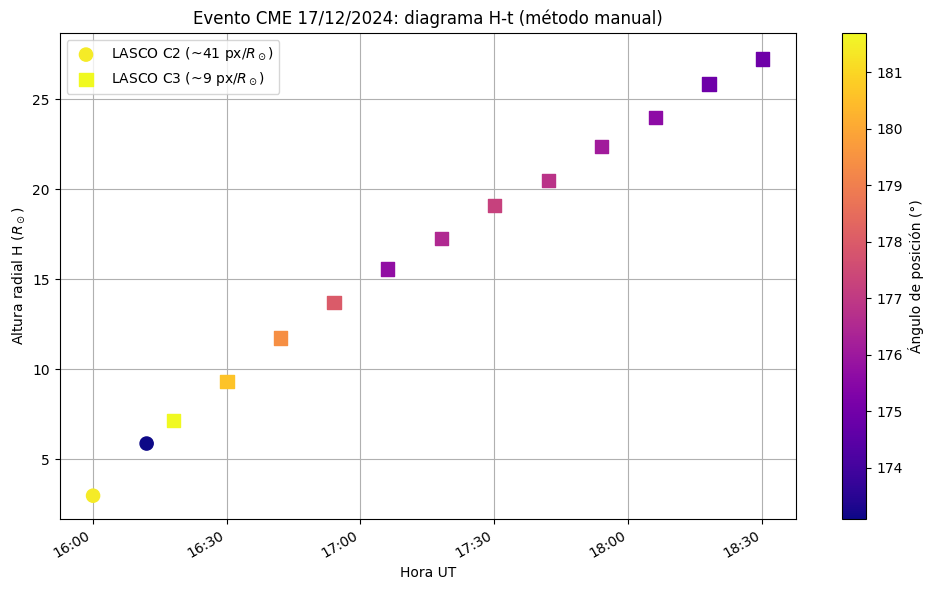

In [7]:
todos_pa = [f["pa_calculado"] for f in tabla]                          # todos los ángulos, para fijar una escala de color común
norma = Normalize(vmin=min(todos_pa), vmax=max(todos_pa))              # la misma escala de color para C2 y C3
fig, ax = plt.subplots(figsize=(10, 6))                                # figura del diagrama
for detector, marcador in [("C2", "o"), ("C3", "s")]:                  # círculos para C2, cuadrados para C3
    filas = [f for f in tabla if f["detector"] == detector]            # filas de este detector
    t = [datetime.strptime(f["tiempo_utc"], "%Y-%m-%d %H:%M:%S") for f in filas]   # horas
    h = [f["altura_rsun"] for f in filas]                              # alturas
    e = [f["sigma_rsun"] for f in filas]                               # incertidumbres
    ax.errorbar(t, h, yerr=e, fmt="none", ecolor="gray", capsize=2, zorder=1)      # barras de error (detrás de los puntos)
    sc = ax.scatter(t, h, c=[f["pa_calculado"] for f in filas], cmap="plasma", norm=norma,
                    marker=marcador, s=90, zorder=2, label=f"LASCO {detector} (~{PX_POR_RSUN[detector]:.0f} px/$R_\\odot$)")  # puntos coloreados
fig.colorbar(sc, ax=ax, label="Ángulo de posición (°)")                # una sola barra de color para ambos detectores
ax.set_xlabel("Hora UT")                                               # eje x
ax.set_ylabel(r"Altura radial H ($R_\odot$)")                          # eje y con símbolo solar (mathtext)
ax.set_title("Evento CME 17/12/2024: diagrama H-t (método manual)")    # título
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))            # horas como HH:MM
ax.grid(True)                                                          # cuadrícula
ax.legend()                                                            # leyenda
fig.autofmt_xdate()                                                    # inclina las horas
fig.tight_layout()                                                     # acomoda márgenes
fig.savefig("diagrama_ht_manual_evento1.png", dpi=150)                 # guarda la figura
plt.show()                                                             # la muestra en pantalla